In [9]:
import sys
!{sys.executable} -m pip install opencv-python numpy matplotlib scikit-image

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.0 MB 916.2 kB/s eta 0:00:48
   ---------------------------------------- 0.5/44.0 MB 916.2 kB/s eta 0:00:48
   ---------------------------------------- 0.5/44.0 MB 916.2 kB/s eta 0:00:48
    --------------------------------------- 0.8/44.0 MB 577.4 kB/s eta 0:01:15
    --------------------------------------- 1.0/44.0 MB 691.5 kB/s eta 0:01:03
    --------------------------------------- 1.0/44.0 MB 691.5 kB/s eta 0:01:03
   - -------------------------------------- 1.3/44.0 MB 644.7 kB/s eta 0:01:07
   - -------------------------------------- 1.6/44.0 MB 702.6 kB/s eta 0:01:01
   - -------------

In [10]:
# Cell 1: Libraries Import & Settings
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Optional: To calculate metrics for Mode A comparison
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Configure inline plot sizing
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8)
print("Libraries imported successfully!")


Libraries imported successfully!


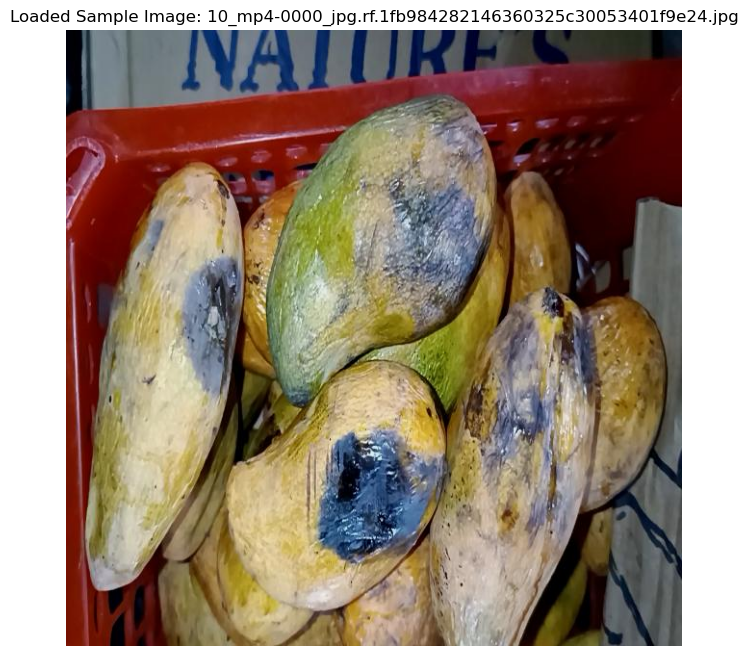

Successfully loaded 4932 training images!


In [14]:
# Cell 2: Define Dataset Directory and Load Sample Image
import os
import cv2
import matplotlib.pyplot as plt

# Updated path pointing directly to your 'train' folder
DATASET_PATH = os.path.expanduser(r"~\Downloads\image processing\mango_dataset\train")

# Find all image files (.jpg, .png) in the train folder
image_files = [f for f in os.listdir(DATASET_PATH) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if not image_files:
    print("Error: No images found in directory! Check your path.")
else:
    # Read the first sample image
    sample_img_path = os.path.join(DATASET_PATH, image_files[0])
    raw_img = cv2.imread(sample_img_path)
    
    # Convert BGR to RGB for matplotlib rendering
    raw_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    
    plt.imshow(raw_rgb)
    plt.title(f"Loaded Sample Image: {image_files[0]}")
    plt.axis('off')
    plt.show()
    print(f"Successfully loaded {len(image_files)} training images!")

In [17]:
# Cell 3: Algorithm Functions

# 1. Colour Constancy: Gray World
def apply_gray_world(img):
    img_float = img.astype(np.float32)
    avg_b, avg_g, avg_r = np.mean(img_float[:, :, 0]), np.mean(img_float[:, :, 1]), np.mean(img_float[:, :, 2])
    gray_avg = (avg_b + avg_g + avg_r) / 3.0
    
    img_float[:, :, 0] *= (gray_avg / (avg_b + 1e-5))
    img_float[:, :, 1] *= (gray_avg / (avg_g + 1e-5))
    img_float[:, :, 2] *= (gray_avg / (avg_r + 1e-5))
    return np.clip(img_float, 0, 255).astype(np.uint8)

# 2. Illumination Correction: Multi-Scale Retinex (MSR)
def apply_msr(img, sigmas=[15, 80, 250]):
    img_float = img.astype(np.float32) + 1.0
    msr = np.zeros_like(img_float)
    for sigma in sigmas:
        blur = cv2.GaussianBlur(img_float, (0, 0), sigma)
        msr += np.log10(img_float) - np.log10(blur + 1e-5)
    msr /= len(sigmas)
    
    for i in range(3):
        min_v, max_v = np.min(msr[:, :, i]), np.max(msr[:, :, i])
        msr[:, :, i] = (msr[:, :, i] - min_v) / (max_v - min_v + 1e-5) * 255.0
    return np.clip(msr, 0, 255).astype(np.uint8)

# 3. Contrast Enhancement: CLAHE
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2BGR)

# 4. Denoising: Bilateral Filter
def apply_bilateral(img):
    return cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

# 5. Segmentation: GrabCut
def apply_grabcut(img):
    mask = np.zeros(img.shape[:2], np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)
    h, w = img.shape[:2]
    rect = (int(w * 0.05), int(h * 0.05), int(w * 0.9), int(h * 0.9))
    cv2.grabCut(img, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)
    binary_mask = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
    return img * binary_mask[:, :, np.newaxis], binary_mask

# 6. Feature / Blemish Extraction: Sobel Operator
def apply_sobel(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = cv2.magnitude(sobel_x, sobel_y)
    return np.clip(mag, 0, 255).astype(np.uint8)

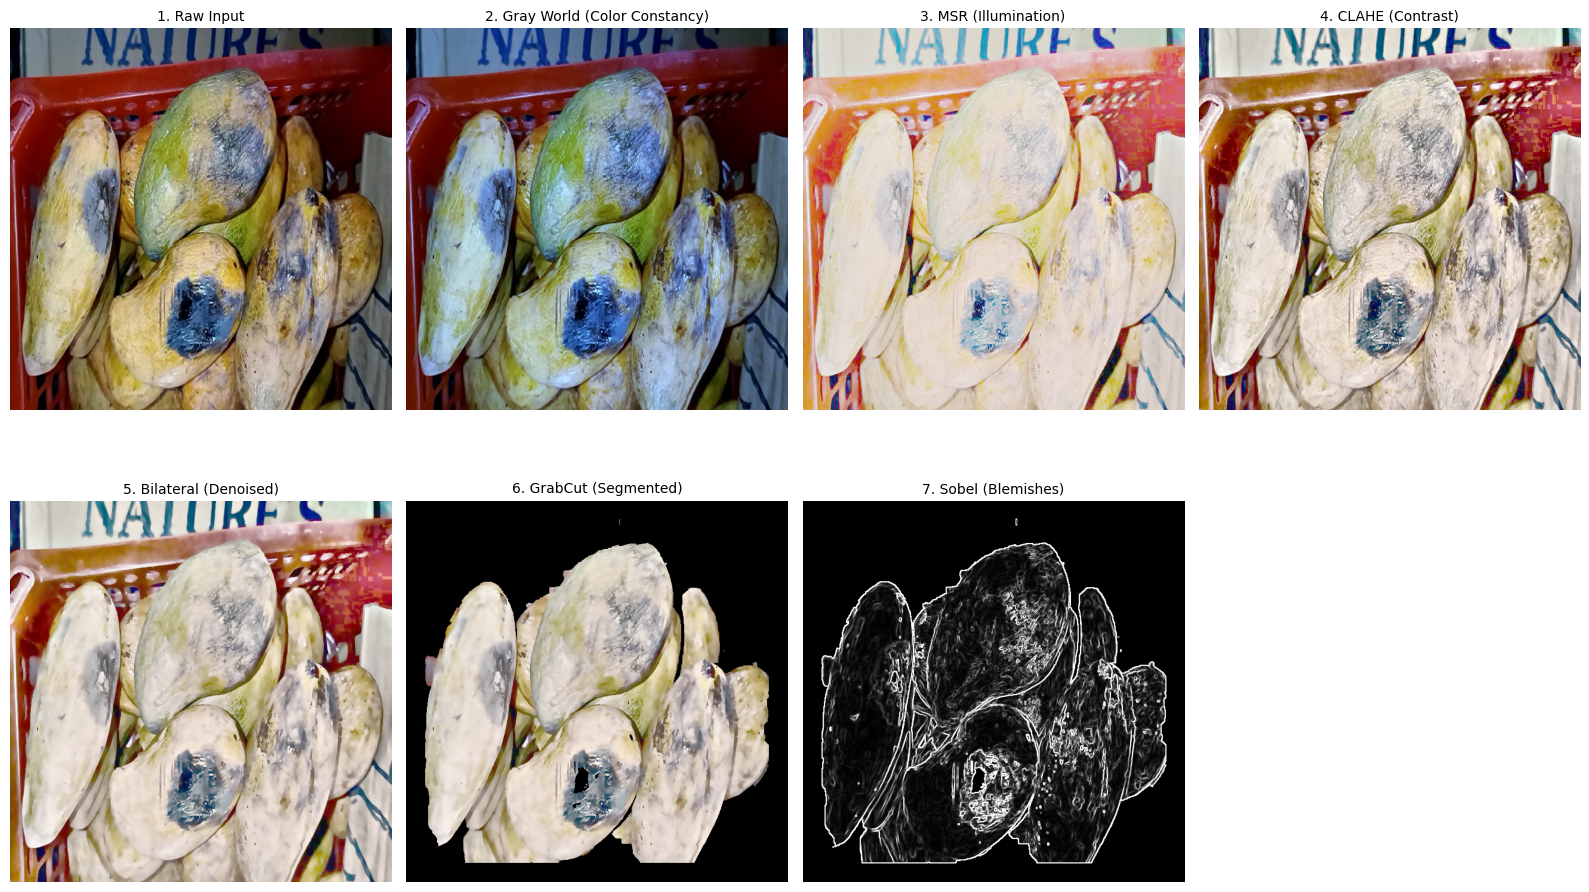

In [18]:
# Cell 4: Execute Sequential Pipeline

# Execute steps
step1_cc = apply_gray_world(raw_img)
step2_msr = apply_msr(step1_cc)
step3_clahe = apply_clahe(step2_msr)
step4_denoise = apply_bilateral(step3_clahe)
step5_seg, mask = apply_grabcut(step4_denoise)
step6_sobel = apply_sobel(step5_seg)

# Display Grid
titles = [
    "1. Raw Input", "2. Gray World (Color Constancy)", "3. MSR (Illumination)",
    "4. CLAHE (Contrast)", "5. Bilateral (Denoised)", "6. GrabCut (Segmented)", "7. Sobel (Blemishes)"
]

outputs = [
    raw_rgb,
    cv2.cvtColor(step1_cc, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(step2_msr, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(step3_clahe, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(step4_denoise, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(step5_seg, cv2.COLOR_BGR2RGB),
    step6_sobel
]

plt.figure(figsize=(16, 10))
for i in range(len(outputs)):
    plt.subplot(2, 4, i + 1)
    if len(outputs[i].shape) == 2:
        plt.imshow(outputs[i], cmap='gray')
    else:
        plt.imshow(outputs[i])
    plt.title(titles[i], fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()